In [1]:
import xgboost

print ("hello pre processing")

hello pre processing


In [2]:
import numpy as np
import pandas as pd
import sklearn 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/ai4i2020.csv')
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


# حذف ستون‌های غیرضروری و خطرناک

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [5]:
cols_to_drop = ['UDI' , 'Product ID' , 'TWF' , 'HDF' , 'PWF' , 'OSF' , 'RNF']

df_clean = df.drop(columns=cols_to_drop)
print(df_clean.shape)
print(df_clean.columns.tolist())

(10000, 7)
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


# تبدیل ستون دسته‌ای Type به عدد (One-Hot Encoding)

In [6]:
df_encoded = pd.get_dummies(df_clean, columns=['Type'], drop_first=True)

print(df_encoded.head())
print(df_encoded.dtypes)

   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  Type_L  Type_M  
0         42.8                0                0   False    True  
1         46.3                3                0    True   False  
2         49.4                5                0    True   False  
3         39.5                7                0    True   False  
4         40.0                9                0    True   False  
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool we

# جدا کردن X (فیچرها/ورودی‌ها) از y (هدف/خروجی که می‌خوایم پیش‌بینی کنیم)


In [7]:


df_encoded.columns = (
    df_encoded.columns
    .str.replace('[', '_', regex=False)
    .str.replace(']', '_', regex=False)
    .str.replace('<', '_', regex=False)
)

print(df_encoded.head)

<bound method NDFrame.head of       Air temperature _K_  Process temperature _K_  Rotational speed _rpm_  \
0                   298.1                    308.6                    1551   
1                   298.2                    308.7                    1408   
2                   298.1                    308.5                    1498   
3                   298.2                    308.6                    1433   
4                   298.2                    308.7                    1408   
...                   ...                      ...                     ...   
9995                298.8                    308.4                    1604   
9996                298.9                    308.4                    1632   
9997                299.0                    308.6                    1645   
9998                299.0                    308.7                    1408   
9999                299.0                    308.7                    1500   

      Torque _Nm_  Tool wear _min

In [8]:
X = df_encoded.drop(columns=["Machine failure"])
y = df_encoded["Machine failure"]

# تقسیم داده به Train/Test

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X , y , test_size = 0.2, random_state = 42 , stratify = y)

print (X_train.shape, X_test.shape)
print (y_train.value_counts(normalize = True)*100)
print (y_test.value_counts(normalize = True)*100)

(8000, 7) (2000, 7)
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


# نرمال‌سازی (StandardScaler)

In [10]:
from sklearn.preprocessing import StandardScaler

numeric_cols= ['Air temperature _K_', 'Process temperature _K_','Rotational speed _rpm_', 'Torque _Nm_', 'Tool wear _min_']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(X_train_scaled[numeric_cols].describe())

       Air temperature _K_  Process temperature _K_  Rotational speed _rpm_  \
count         8.000000e+03             8.000000e+03            8.000000e+03   
mean          1.758593e-15             1.053468e-14            3.010925e-16   
std           1.000063e+00             1.000063e+00            1.000063e+00   
min          -2.356591e+00            -2.910801e+00           -2.052017e+00   
25%          -8.541261e-01            -8.152711e-01           -6.484822e-01   
50%           4.735268e-02             6.349964e-02           -2.008982e-01   
75%           7.485028e-01             7.394771e-01            4.069319e-01   
max           2.250967e+00             2.564616e+00            7.441184e+00   

        Torque _Nm_  Tool wear _min_  
count  8.000000e+03     8.000000e+03  
mean  -1.474376e-16    -3.064216e-17  
std    1.000063e+00     1.000063e+00  
min   -3.613500e+00    -1.692947e+00  
25%   -6.790515e-01    -8.597185e-01  
50%    9.645501e-03    -1.076908e-02  
75%    6.783803

# SMOTE و متوازن سازی داده ها در قسمت میزان خرابی و سالم بودن

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(X_train_scaled.shape)
print (X_train_resampled.shape)
print (y_train_resampled.value_counts())
print (y_train_resampled.value_counts(normalize = True)*100)

(8000, 7)
(15458, 7)
Machine failure
0    7729
1    7729
Name: count, dtype: int64
Machine failure
0    50.0
1    50.0
Name: proportion, dtype: float64


# مدل پایه (Baseline)

### پیاده‌سازی Logistic Regression ساده (بدون تنظیم پارامتر خاص) به‌عنوان نقطه‌ی مرجع

In [12]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_resampled , y_train_resampled)

y_pred_log = log_reg.predict(X_test_scaled)
print (y_pred_log[:20])
print (y_test.values[:20])


[1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [13]:
#from sklearn.metrics import accuracy_score

#acc_test_log = accuracy_score(y_test , y_pred_log)

#acc_test_log

# Random forest and xgboost

In [14]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test_scaled)

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb.predict(X_test_scaled)

print(y_pred_rf[:20])
print(y_pred_xgb[:20])
print(y_test.values[:20])

[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [15]:
#from sklearn.metrics import accuracy_score
#from sklearn.metrics import recall_score
#from sklearn.metrics import precision_score

#rf_acc = accuracy_score(y_test, y_pred_rf)
#rf_rec = recall_score(y_test, y_pred_rf)
#rf_pre = precision_score(y_test, y_pred_rf)
#print (rf_acc , rf_rec , rf_pre)

#xgb_acc = accuracy_score(y_test, y_pred_xgb)
#xgb_rec = recall_score(y_test, y_pred_xgb)
#xgb_pre = precision_score(y_test, y_pred_xgb)
#print(xgb_acc , xgb_rec , xgb_pre)

# استفاده از Cross-Validation (مثلاً K-Fold) برای ارزیابی پایدارتر مدل‌ها

In [16]:
from sklearn.model_selection import cross_val_score

models = {
    "logistic regression": log_reg,
    "random forest": rf,
    "xgboost": xgb,
}

for name , model in models.items():
    scores = cross_val_score(model , X_train_resampled, y_train_resampled, cv=5 , scoring="f1")
    print (f"{name} mean F1 = {scores.mean():.4f}, std = {scores.std():.4f}")
    print(f"  scores per fold: {scores}")

logistic regression mean F1 = 0.8304, std = 0.0043
  scores per fold: [0.82414698 0.83655084 0.83221904 0.82731451 0.83171521]
random forest mean F1 = 0.9830, std = 0.0026
  scores per fold: [0.98290874 0.98683788 0.97885971 0.98241126 0.98394348]
xgboost mean F1 = 0.9884, std = 0.0031
  scores per fold: [0.98836458 0.99324107 0.98366955 0.98715478 0.98938565]


# پیدا کردن و تنظیم کردن هایپر پارامتر ها با randomizedsearchcv

In [17]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train_resampled, y_train_resampled)

print("Best RF params:", rf_search.best_params_)
print("Best RF F1:", rf_search.best_score_)


xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    xgb_param_grid,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train_resampled, y_train_resampled)

print("Best XGB params:", xgb_search.best_params_)
print("Best XGB F1:", xgb_search.best_score_)

Best RF params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 30}
Best RF F1: 0.9825977358398615
Best XGB params: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2}
Best XGB F1: 0.9889353329138311


In [18]:
best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

# ارزیابی مدل‌ها

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

models_final = {
    'Logistic Regression': log_reg,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

for name, model in models_final.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print()

===== Logistic Regression =====
              precision    recall  f1-score   support

           0     0.9921    0.8401    0.9098      1932
           1     0.1511    0.8088    0.2546        68

    accuracy                         0.8390      2000
   macro avg     0.5716    0.8244    0.5822      2000
weighted avg     0.9635    0.8390    0.8875      2000

Confusion Matrix:
[[1623  309]
 [  13   55]]
ROC-AUC: 0.8958

===== Random Forest =====
              precision    recall  f1-score   support

           0     0.9910    0.9741    0.9825      1932
           1     0.5050    0.7500    0.6036        68

    accuracy                         0.9665      2000
   macro avg     0.7480    0.8621    0.7930      2000
weighted avg     0.9745    0.9665    0.9696      2000

Confusion Matrix:
[[1882   50]
 [  17   51]]
ROC-AUC: 0.9743

===== XGBoost =====
              precision    recall  f1-score   support

           0     0.9932    0.9850    0.9891      1932
           1     0.6548    0.8088  

# توجیه این که چرا ترش هولد به کمک ما نمیاد تغییرش
 

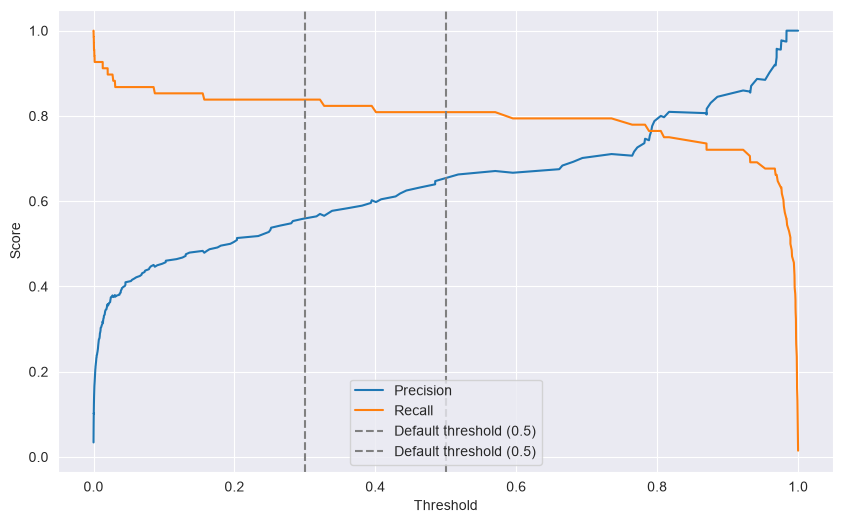

In [20]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.axvline(x=0.3, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.savefig('../reports/precision_recall_vs_threshold.png')
plt.show()

In [21]:
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    print(f"--- Threshold = {t} ---")
    print(classification_report(y_test, y_pred_t, digits=4))
    

--- Threshold = 0.3 ---
              precision    recall  f1-score   support

           0     0.9942    0.9772    0.9856      1932
           1     0.5644    0.8382    0.6746        68

    accuracy                         0.9725      2000
   macro avg     0.7793    0.9077    0.8301      2000
weighted avg     0.9796    0.9725    0.9751      2000

--- Threshold = 0.4 ---
              precision    recall  f1-score   support

           0     0.9932    0.9808    0.9870      1932
           1     0.5978    0.8088    0.6875        68

    accuracy                         0.9750      2000
   macro avg     0.7955    0.8948    0.8372      2000
weighted avg     0.9797    0.9750    0.9768      2000

--- Threshold = 0.5 ---
              precision    recall  f1-score   support

           0     0.9932    0.9850    0.9891      1932
           1     0.6548    0.8088    0.7237        68

    accuracy                         0.9790      2000
   macro avg     0.8240    0.8969    0.8564      2000
we

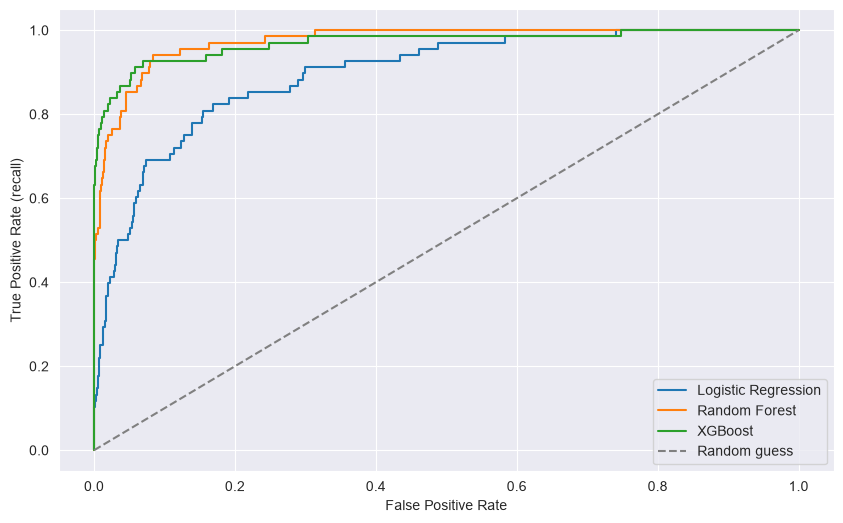

In [22]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 6))


models_final = {
    'Logistic Regression': log_reg,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

for name , model in models_final.items():
    y_proba = model.predict_proba(X_test_scaled)[: , 1]
    fpr , tpr , _ = roc_curve(y_test , y_proba)
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel("True Positive Rate (recall)")
plt.legend()
plt.savefig("../reports/roc_curve_comparison.png")
plt.show()

                   feature  importance
2   Rotational speed _rpm_    0.322031
3              Torque _Nm_    0.249641
4          Tool wear _min_    0.198441
6                   Type_M    0.070463
0      Air temperature _K_    0.066088
5                   Type_L    0.051715
1  Process temperature _K_    0.041620


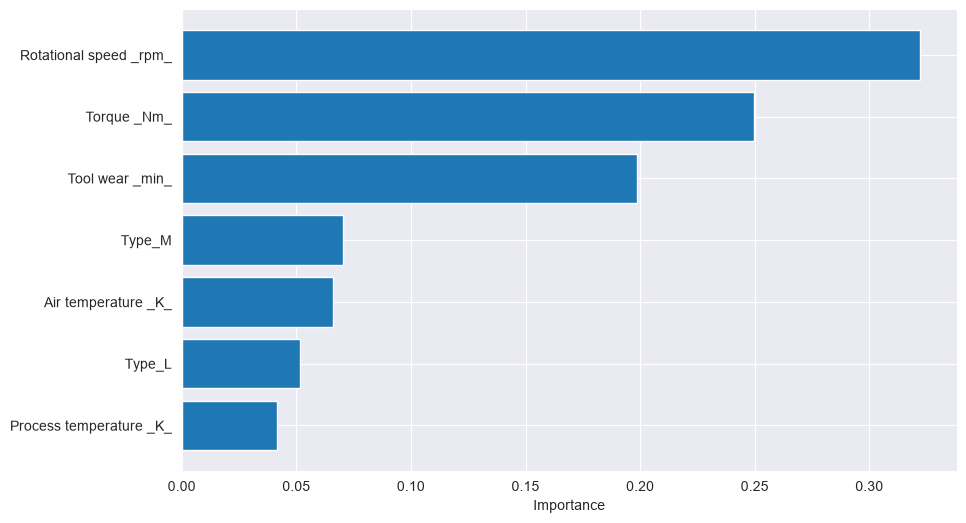

In [23]:
importances = best_xgb.feature_importances_
feature_names = X_train_resampled.columns

feat_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance_df['feature'], feat_importance_df['importance'])
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.savefig('../reports/feature_importance_xgb.png')
plt.show()

                   feature  importance
3              Torque _Nm_    0.312139
2   Rotational speed _rpm_    0.280454
4          Tool wear _min_    0.204366
0      Air temperature _K_    0.101663
1  Process temperature _K_    0.065102
5                   Type_L    0.021929
6                   Type_M    0.014347


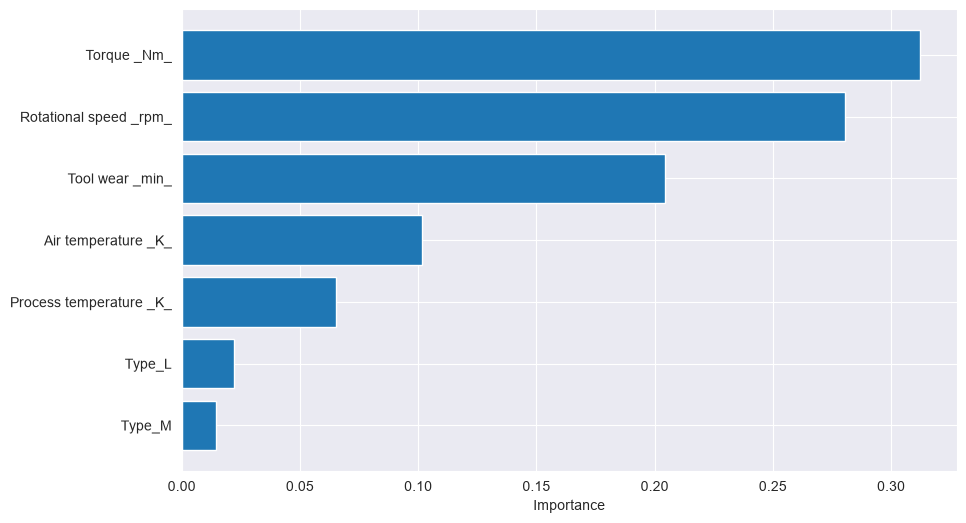

In [24]:
importances = best_rf.feature_importances_
feature_names = X_train_resampled.columns

feat_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance_df['feature'], feat_importance_df['importance'])
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.savefig('../reports/feature_importance_rf.png')
plt.show()